# Praktikum Hierarchical Clustering
### Week/Sesi: 5/3 | Nama: Tika Altiora Sitanggang | NIM: 42324025

Hierarchical Clustering adalah metode klasterisasi yang mengelompokkan data secara bertahap sampai membentuk hierarki seperti pohon. Hasilnya digambar dalam bentuk dendrogram. Berbeda dengan K-Means, di sini kita tidak perlu menentukan jumlah klaster di awal.

Ada dua pendekatan:

| Pendekatan | Cara kerja |
|---|---|
| Agglomerative (bottom up) | Mulai dari setiap data sebagai satu klaster sendiri, lalu klaster yang paling dekat digabung sedikit demi sedikit sampai tinggal satu. Ini yang dipakai di praktikum ini. |
| Divisive (top down) | Mulai dari satu klaster besar berisi semua data, lalu dipecah sedikit demi sedikit. |

Cara mengukur jarak antar klaster disebut linkage. Ada tiga yang dipakai di praktikum ini:

| Linkage | Jarak antar klaster diambil dari |
|---|---|
| Single | Jarak terdekat antara dua titik dari klaster yang berbeda |
| Complete | Jarak terjauh antara dua titik dari klaster yang berbeda |
| Average | Rata-rata jarak semua pasangan titik dari klaster yang berbeda |

Isi praktikum:
1. Percobaan 1: dataset sederhana (6 titik) dengan single linkage.
2. Percobaan 2: dataset Mall Customers dengan complete linkage.
3. Tugas: membandingkan dendrogram single, complete, dan average linkage pada dataset sederhana.

## 2. Percobaan 1: Dataset Sederhana

Percobaan pertama memakai 6 titik data dua dimensi (a sampai f) supaya proses penggabungan klasternya gampang diikuti.

### 2.1 Import Library, Membuat Dataset, dan Menghitung Distance Matrix

Di sel ini kita import library yang dibutuhkan, membuat 6 titik data, lalu menghitung jarak Euclidean antar semua pasangan titik. pdist menghasilkan jarak dalam bentuk daftar, lalu squareform mengubahnya jadi matriks persegi supaya lebih mudah dibaca.

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                           columns=['a', 'b', 'c', 'd', 'e', 'f'],
                           index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


Hasil di atas adalah distance matrix. Beberapa hal yang bisa dilihat:
- Matriks simetris dan diagonalnya 0, karena jarak sebuah titik ke dirinya sendiri adalah 0.
- Pasangan paling dekat adalah d dan f dengan jarak 0.5, jadi keduanya akan digabung paling awal.
- Berikutnya a dan b (0.707), lalu d dan e (1.0).
- Pasangan paling jauh adalah a dan c (5.657), jadi keduanya baru akan bertemu di penggabungan terakhir.

### 2.2 Hierarchical Clustering (Single Linkage) dan Dendrogram

Fungsi linkage dengan method single menjalankan agglomerative clustering, dengan jarak antar klaster diambil dari titik yang paling dekat. Lalu dendrogram digambar. Sumbu X berisi titik data, sumbu Y berisi jarak saat dua klaster digabung. Makin tinggi garis penggabungannya, makin berbeda kedua klaster itu.

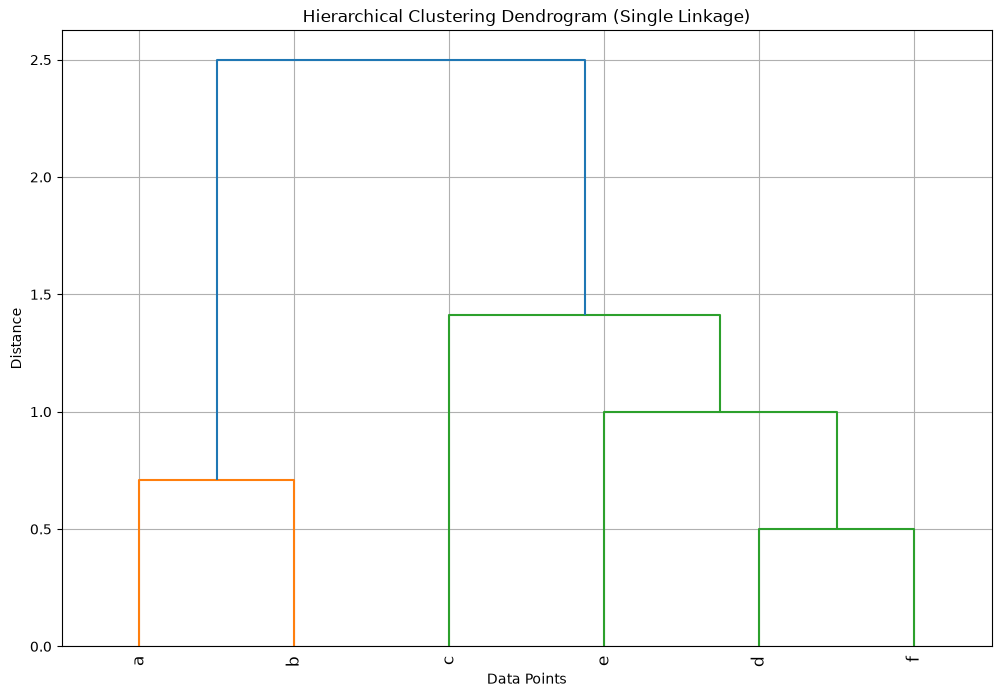

In [2]:
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Urutan penggabungan pada dendrogram single linkage:

| Langkah | Yang digabung | Jarak |
|---|---|---|
| 1 | d dan f | 0.5 |
| 2 | a dan b | 0.707 |
| 3 | e dengan (d, f) | 1.0 |
| 4 | c dengan (d, e, f) | 1.414 |
| 5 | (a, b) dengan (c, d, e, f) | 2.5 |

Terbentuk dua kelompok besar, yaitu (a, b) di kiri dan (c, d, e, f) di kanan. Garis penggabungan terakhir di jarak 2.5 jauh lebih tinggi dari yang lain, artinya dua kelompok ini memang cukup berbeda.

### 2.3 Melihat Linkage Matrix (Tambahan)

Hasil linkage sebenarnya berupa matriks. Di sel ini matriksnya ditampilkan sebagai tabel supaya langkah penggabungan lebih jelas. Kolom 1 dan 2 adalah klaster yang digabung (nomor 0 sampai 5 adalah titik asli, nomor 6 ke atas adalah klaster baru hasil gabungan), kolom 3 adalah jaraknya, dan kolom 4 adalah jumlah anggota klaster baru.

In [3]:
linked_df = pd.DataFrame(linked,
                         columns=['Klaster 1', 'Klaster 2', 'Jarak', 'Jumlah Anggota'])
linked_df[['Klaster 1', 'Klaster 2', 'Jumlah Anggota']] = linked_df[['Klaster 1', 'Klaster 2', 'Jumlah Anggota']].astype(int)
linked_df.index = [f'Langkah {i+1}' for i in range(len(linked_df))]
linked_df

,Klaster 1,Klaster 2,Jarak,Jumlah Anggota
Langkah 1,3,5,0.500000,2
Langkah 2,0,1,0.707107,2
Langkah 3,4,6,1.000000,3
Langkah 4,2,8,1.414214,4
Langkah 5,7,9,2.500000,6


Tabel ini isinya sama dengan tabel langkah di atas. Contohnya di Langkah 1, klaster 3 (titik d) dan 5 (titik f) digabung pada jarak 0.5 dan menjadi klaster baru bernomor 6 yang beranggota 2 titik. Klaster nomor 6 ini yang dipakai di langkah selanjutnya.

## 3. Percobaan 2: Dataset Mall Customers

Percobaan kedua memakai dataset Mall Customers untuk mengelompokkan pelanggan berdasarkan dua fitur, yaitu Annual Income (pendapatan tahunan) dan Spending Score (skor pengeluaran 1 sampai 100). Tujuannya supaya pelanggan dengan pola pengeluaran yang mirip berada di klaster yang sama.

### 3.1 Load Dataset

File Mall_Customers.csv dibaca dengan pd.read_csv. File ini ditaruh satu folder dengan notebook (Week 5 \ Sesi 3), jadi cukup dipanggil dengan nama filenya. df.head() menampilkan 5 baris pertama.

In [4]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Dataset punya 5 kolom: CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100). Satu baris mewakili satu pelanggan.

### 3.2 Cek Ukuran dan Informasi Dataset (Tambahan)

Sebelum diproses, dicek dulu jumlah baris dan kolom, tipe datanya, dan apakah ada nilai yang kosong.

In [5]:
print("Ukuran dataset (baris, kolom):", df.shape)
print()
df.info()
print()
print("Jumlah nilai kosong per kolom:")
print(df.isnull().sum())

Ukuran dataset (baris, kolom): (200, 5)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB

Jumlah nilai kosong per kolom:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Dataset berisi 200 pelanggan dengan 5 kolom dan tidak ada nilai kosong, jadi tidak perlu dibersihkan lagi.

### 3.3 Memilih Fitur

df.iloc[:, [3, 4]] mengambil semua baris dari kolom ke 3 (Annual Income) dan kolom ke 4 (Spending Score). Tanda .values mengubahnya jadi array NumPy.

In [6]:
x = df.iloc[:, [3, 4]].values
x[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

x sekarang berisi dua kolom, yaitu income dan spending score. Lima baris pertamanya sama dengan hasil df.head() di atas.

### 3.4 Standarisasi Data (StandardScaler)

Hierarchical Clustering bekerja dengan jarak, jadi fitur yang angkanya besar bisa mendominasi fitur yang angkanya kecil. Karena itu data distandarisasi dulu pakai StandardScaler, sehingga tiap fitur punya rata-rata 0 dan standar deviasi 1. Rumusnya:

$$z = \frac{x - \mu}{\sigma}$$

In [7]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Output (200, 2) artinya ada 200 pelanggan dan 2 fitur setelah distandarisasi.

### 3.5 Hierarchical Clustering (Complete Linkage)

Di sini dipakai complete linkage, jadi jarak antar klaster diambil dari pasangan titik yang paling jauh. Metrik jaraknya Euclidean.

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

Sel ini tidak menampilkan output karena hasilnya disimpan di variabel clustering. Isinya linkage matrix berukuran 199 x 4, yaitu 199 kali penggabungan untuk 200 data. Matriks ini digambar di sel berikutnya.

### 3.6 Plot Dendrogram

Dendrogram digambar dari linkage matrix tadi. Label di sumbu X terlihat menumpuk karena ada 200 pelanggan, itu wajar. Yang perlu dilihat adalah warna cabang dan tinggi penggabungannya.

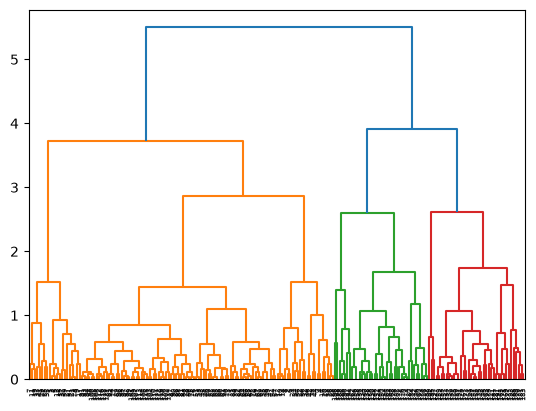

In [9]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Dendrogram membagi pelanggan menjadi tiga kelompok utama, yaitu oranye, hijau, dan merah. Pembagian ini membantu membuat segmentasi pelanggan untuk strategi pemasaran yang lebih tepat sasaran, misalnya pelanggan dengan pengeluaran rendah, sedang, dan tinggi, sehingga penawaran yang diberikan bisa disesuaikan untuk tiap kelompok.

Warna cabang muncul otomatis karena SciPy memotong pohon di sekitar 0.7 kali jarak penggabungan tertinggi.

### 3.7 Dendrogram dengan Judul dan Label (Tambahan)

Ini versi yang lebih rapi untuk laporan: ada judul, label sumbu, ukuran gambar lebih besar, dan label tiap pelanggan dihilangkan (no_labels=True) supaya sumbu X tidak penuh tulisan.

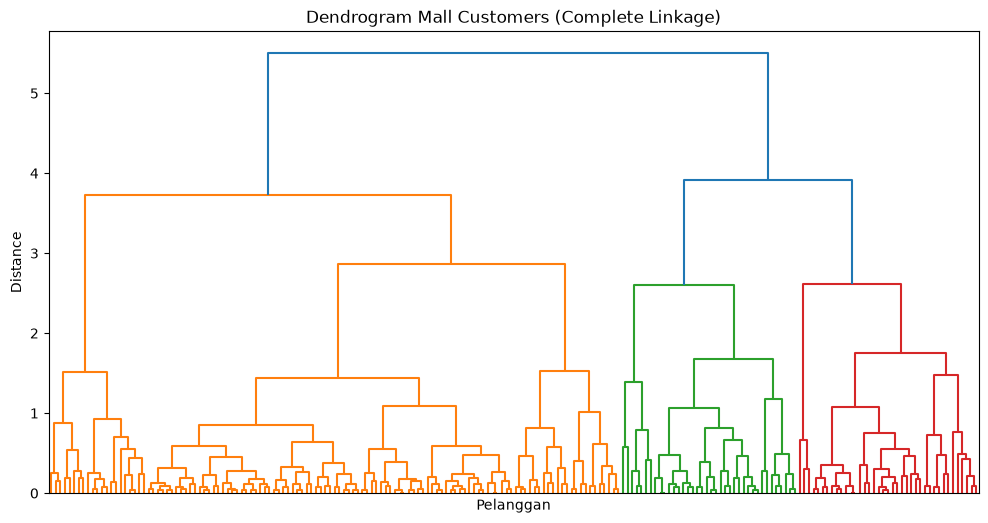

In [10]:
plt.figure(figsize=(12, 6))
plt.title("Dendrogram Mall Customers (Complete Linkage)")
dendrogram(clustering, no_labels=True)
plt.xlabel("Pelanggan")
plt.ylabel("Distance")
plt.show()

Bentuknya sama dengan dendrogram sebelumnya, hanya tampilannya lebih bersih.

### 3.8 Memotong Dendrogram Menjadi 3 Klaster (Tambahan)

Supaya tiap pelanggan punya label klaster, dendrogram dipotong dengan fcluster (t=3, criterion maxclust) sehingga terbentuk tepat 3 klaster. Hasilnya diplot sebagai scatter plot dengan skala data asli.

Jumlah pelanggan per klaster:
Cluster
1    123
2     38
3     39
Name: count, dtype: int64


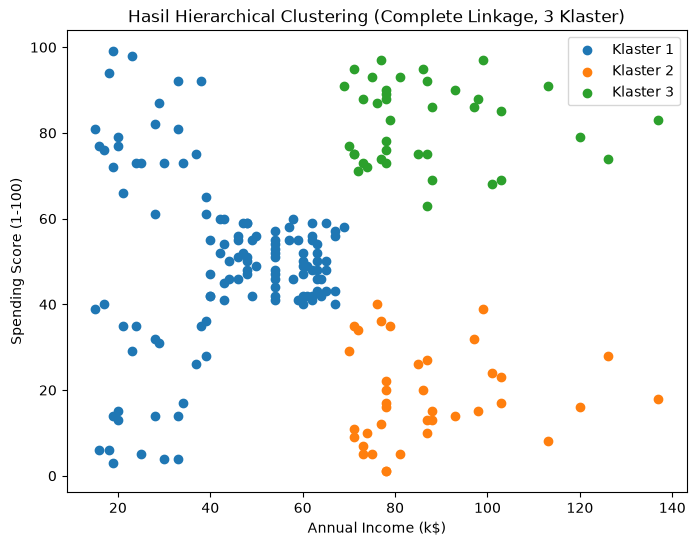

In [11]:
from scipy.cluster.hierarchy import fcluster

labels = fcluster(clustering, t=3, criterion='maxclust')
df['Cluster'] = labels

print("Jumlah pelanggan per klaster:")
print(df['Cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 6))
for k in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == k]
    plt.scatter(sub['Annual Income (k$)'], sub['Spending Score (1-100)'], label=f'Klaster {k}')
plt.title("Hasil Hierarchical Clustering (Complete Linkage, 3 Klaster)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

Scatter plot memperlihatkan pelanggan terbagi jadi 3 klaster berdasarkan kombinasi income dan spending score. Jumlah anggotanya 123, 38, dan 39 pelanggan. Sel berikutnya menghitung rata-rata tiap klaster supaya bisa diberi nama.

In [12]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
1,44.15,49.83
2,87.00,18.63
3,86.54,82.13


Dari rata-ratanya, klaster 1 punya income dan spending score sedang (sekitar 44 dan 50), klaster 2 punya income tinggi tapi spending score rendah (sekitar 87 dan 19), dan klaster 3 punya income tinggi dan spending score tinggi (sekitar 87 dan 82). Klaster 3 adalah pelanggan yang paling potensial untuk diberi penawaran khusus.

## 4. Tugas

Soal: pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage dan average linkage.

### 4.1 Plot Tiga Dendrogram Berdampingan

Dataset sederhana dari Percobaan 1 dipakai lagi. Ketiga metode dijalankan, lalu dendrogramnya digambar berdampingan. Sumbu Y dibuat sama (sharey=True) supaya tinggi penggabungannya bisa dibandingkan dengan adil.

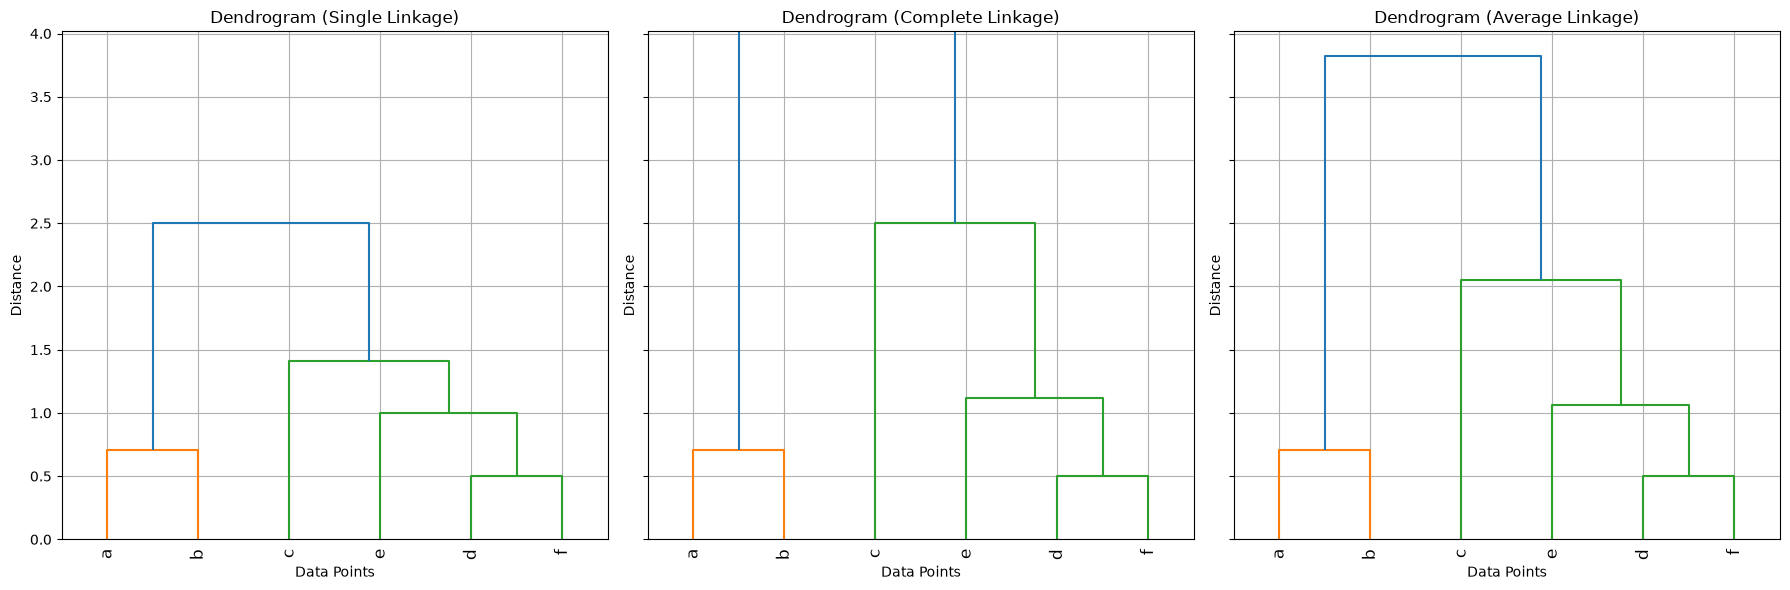

In [13]:
labels_pts = ['a', 'b', 'c', 'd', 'e', 'f']
methods = ['single', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, m in zip(axes, methods):
    Z = linkage(data, method=m)
    dendrogram(Z, labels=labels_pts, leaf_rotation=90, ax=ax)
    ax.set_title(f"Dendrogram ({m.capitalize()} Linkage)")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    ax.grid(True)

plt.tight_layout()
plt.show()

Ketiga dendrogram memakai data yang sama tapi tinggi penggabungannya berbeda. Urutan awalnya mirip, yaitu d dan f serta a dan b selalu digabung paling dulu. Perbedaan paling kelihatan di puncak dendrogram.

### 4.2 Tabel Perbandingan Jarak Penggabungan

Supaya perbandingannya tidak cuma dari tampilan grafik, jarak penggabungan tiap langkah dari ketiga metode dikumpulkan dalam satu tabel.

In [14]:
hasil = {}
for m in methods:
    Z = linkage(data, method=m)
    hasil[m.capitalize()] = np.round(Z[:, 2], 4)

banding_df = pd.DataFrame(hasil, index=[f'Langkah {i+1}' for i in range(len(data) - 1)])
banding_df

,Single,Complete,Average
Langkah 1,0.5000,0.5000,0.5000
Langkah 2,0.7071,0.7071,0.7071
Langkah 3,1.0000,1.1180,1.0590
Langkah 4,1.4142,2.5000,2.0501
Langkah 5,2.5000,5.6569,3.8259


Dari tabel ini:
- Langkah 1 dan 2 nilainya sama untuk ketiga metode. Itu karena yang digabung baru titik tunggal, jadi jarak terdekat, terjauh, dan rata-ratanya sama saja.
- Mulai Langkah 3 nilainya berbeda karena klaster sudah punya lebih dari satu titik. Urutannya selalu single paling kecil, average di tengah, dan complete paling besar.
- Contohnya Langkah 3, saat e digabung dengan klaster (d, f). Jarak e ke d adalah 1.0 (dipakai single), jarak e ke f adalah 1.118 (dipakai complete), dan rata-ratanya 1.059 (dipakai average).

### 4.3 Perbandingan Susunan Klaster untuk 2 dan 3 Klaster (Tambahan)

Untuk mengecek apakah beda linkage mengubah siapa yang sekelompok, dendrogram dipotong jadi 2 dan 3 klaster untuk tiap metode.

In [15]:
from scipy.cluster.hierarchy import fcluster

for m in methods:
    Z = linkage(data, method=m)
    for k in [2, 3]:
        lab = fcluster(Z, t=k, criterion='maxclust')
        grup = {}
        for nama, l in zip(labels_pts, lab):
            grup.setdefault(l, []).append(nama)
        print(f"{m.capitalize():9s} | {k} klaster : {list(grup.values())}")
    print()

Single    | 2 klaster : [['a', 'b'], ['c', 'd', 'e', 'f']]
Single    | 3 klaster : [['a', 'b'], ['c'], ['d', 'e', 'f']]

Complete  | 2 klaster : [['a', 'b'], ['c', 'd', 'e', 'f']]
Complete  | 3 klaster : [['a', 'b'], ['c'], ['d', 'e', 'f']]

Average   | 2 klaster : [['a', 'b'], ['c', 'd', 'e', 'f']]
Average   | 3 klaster : [['a', 'b'], ['c'], ['d', 'e', 'f']]



Susunan klasternya sama untuk ketiga metode. Dengan 2 klaster hasilnya (a, b) dan (c, d, e, f). Dengan 3 klaster, titik c terpisah sendiri sehingga jadi (a, b), (c), dan (d, e, f). Jadi di dataset ini perbedaan linkage hanya terlihat di tinggi penggabungan, bukan di susunan kelompoknya.

### 4.4 Jawaban Tugas

Perbandingan dendrogram single, complete, dan average linkage:

| Aspek | Single | Complete | Average |
|---|---|---|---|
| Jarak antar klaster | Terdekat antar dua titik | Terjauh antar dua titik | Rata-rata semua pasangan titik |
| Tinggi puncak dendrogram | 2.5 (paling rendah) | 5.657 (paling tinggi) | 3.826 (di tengah) |
| Bentuk dendrogram | Seperti tangga bertingkat | Lebih seimbang | Di antara keduanya |
| Titik c digabung pada jarak | 1.414 | 2.5 | 2.050 |
| Kelemahan | Mudah membentuk rantai (chaining) | Sensitif terhadap outlier | Tidak ada yang menonjol |

Kesimpulan tugas:
1. Untuk dataset sederhana ini, ketiga metode menghasilkan urutan penggabungan dan susunan klaster yang sama: d dan f, lalu a dan b, lalu e masuk ke (d, f), lalu c, dan terakhir (a, b) dengan (c, d, e, f).
2. Bedanya ada di tinggi garis penggabungan. Single paling rendah karena hanya melihat tetangga terdekat, complete paling tinggi karena melihat titik terjauh, dan average ada di antaranya.
3. Pada single linkage, titik c langsung menyatu dengan e di jarak rendah (1.414) walaupun c jauh dari d dan f. Ini yang disebut efek chaining, klaster bisa memanjang seperti rantai karena hanya melihat titik yang paling dekat.
4. Pada complete linkage, puncak dendrogram menjadi 5.657 karena yang dilihat adalah jarak terjauh, yaitu a ke c. Satu titik yang letaknya jauh (outlier) bisa membuat jarak antar klaster jadi besar sekali.
5. Average linkage nilainya selalu di tengah, jadi tidak seekstrem dua metode lainnya.
6. Single linkage cocok untuk klaster yang bentuknya memanjang, sedangkan complete dan average lebih cocok untuk klaster yang padat dan seimbang seperti data Mall Customers.

## 5. Kesimpulan Praktikum

1. Hierarchical Clustering mengelompokkan data secara bertahap dan hasilnya digambar sebagai dendrogram, jadi jumlah klaster tidak perlu ditentukan di awal.
2. Pada Percobaan 1 (dataset sederhana, single linkage), d dan f serta a dan b digabung paling awal, lalu terbentuk dua kelompok besar yaitu (a, b) dan (c, d, e, f).
3. Pada Percobaan 2 (Mall Customers, complete linkage), data distandarisasi dulu, lalu dendrogram membagi pelanggan jadi 3 kelompok yang bisa dipakai untuk segmentasi pemasaran.
4. Pada Tugas, perbedaan single, complete, dan average linkage ada di tinggi penggabungan: single (2.5) lebih rendah dari average (3.826), dan average lebih rendah dari complete (5.657). Susunan klaster akhirnya sama.
5. Standarisasi data perlu dilakukan sebelum klasterisasi berbasis jarak supaya semua fitur punya pengaruh yang seimbang.